In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling as modeling
import prism.modeling.models as models
import prism.modeling.display

plt.rcParams['axes.xmargin'] = 0

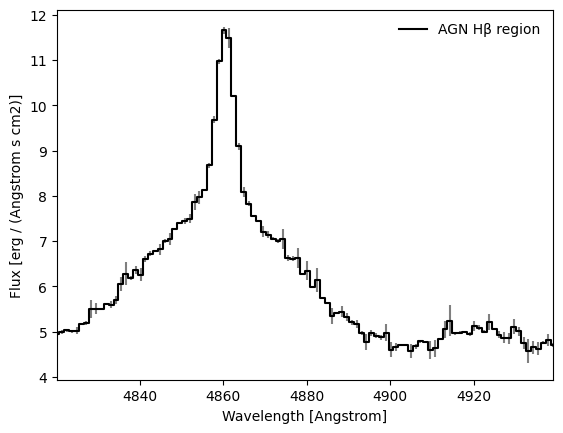

In [2]:
data_path = Path('data/agnspec.txt')   # relative to examples/

dec, ra = -25.12345, 13.12345
redshift = 0.0622

spec = Spectrum.from_txt(
    filename=str(data_path),
    z=redshift,
    ra=ra,
    dec=dec,
    wave_unit=u.AA,
    unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
    name='AGN Hβ region',
)
spec.zcorrect()
spec.deredden()
spec.crop(wbounds=(4820.0, 4940.0))
spec.plot_spectrum()

In [3]:
from prism.modeling.io import load_params, load_model

modelfile = "results/agnmodel.fits"

# params = load_params(modelfile) # parameters dictionary
model = load_model(modelfile) # model object

In [4]:
# # ── Attach parameter uncertainties ───────────────────────────────────────────
# # If the model was saved after covar_attach/resample_attach, uncertainties are
# # already restored and this cell is not needed.
# # Otherwise, re-fit briefly with ScipyTRF to populate .std on parameters.
# # The parameter values from the loaded model are already optimal — the re-fit
# # just computes the covariance around that solution.

# from prism.modeling.fitting.uncertainty import covar_attach

# if not any(getattr(getattr(model, pn), 'std', None) is not None
#            for pn in model.param_names):
#     fitter = fitting.ScipyTRF(calc_uncertainties=True)
#     model = fitter(model, x=spec.wave, y=spec.flux, weights=1.0 / spec.err)
#     covar_attach(model, fitter)
#     print("Uncertainties attached via ScipyTRF covariance.")

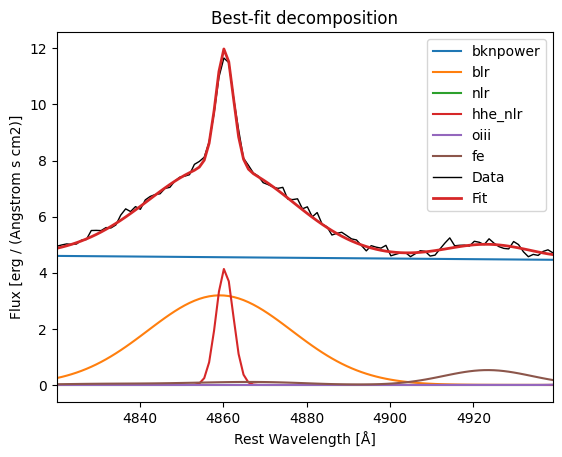

In [5]:
comps = modeling.models.get_components(model, additive=True)

plt.figure()
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, color='black', lw=1, label='Data')
plt.plot(spec.wave, model(spec.wave), color='tab:red', lw=2, label='Fit')

plt.xlabel('Rest Wavelength [Å]')
plt.ylabel(f'Flux [{spec.unit}]')
plt.legend()
plt.title('Best-fit decomposition')
plt.show()

In [6]:
comps.names

['bknpower', 'blr', 'nlr', 'hhe_nlr', 'oiii', 'fe']

In [7]:
# Select_line collects all components contributing to the 'Hb4861' physical tag
hb = modeling.select_line(model=model, selector='Hb4861')
hb

SelectedLineProfile(selector='Hb4861', components=2)

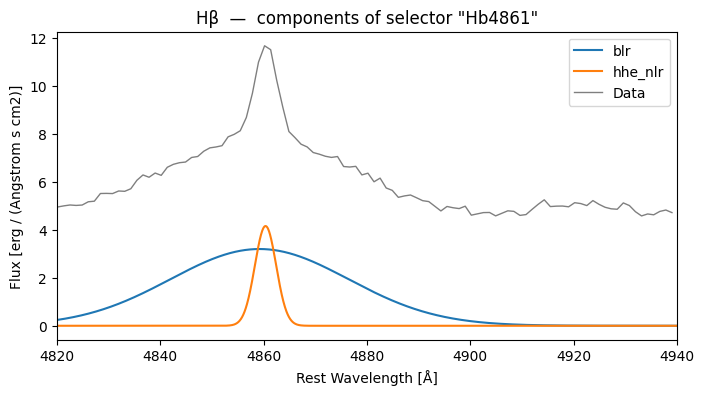

Rest position: 4861.333 Å


In [8]:
# ── Plot each contributing component separately ───────────────────────────────
# evaluate_components() returns a dict {component_name: flux_array}.
# This lets you inspect the individual substructure of the blended line.
wave_hb = np.linspace(4820.0, 4940.0, 2000)

plt.figure(figsize=(8, 4))
for name, flux in hb.evaluate_components(x=wave_hb).items():
    plt.plot(wave_hb, flux, label=name)
plt.plot(spec.wave, spec.flux, color='black', lw=1, alpha=0.5, label='Data')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel(f'Flux [{spec.unit}]')
plt.title(f'Hβ  —  components of selector "{hb.selector}"')
plt.legend()
plt.show()

print(f"Rest position: {hb.position:.3f} Å")

In [9]:
# ── Measurement without uncertainties ────────────────────────────────────────
# hb.measure() integrates the combined profile over an inferred wavelength window.
# Each attribute is a Metric; .value holds the nominal result.
m = hb.measure()

print(f"Flux        : {m.flux.value:.4g}")
print(f"FWHM        : {m.fwhm.value:.4g} Å")
print(f"Centroid    : {m.moment1.value:.4g} Å")
print(f"Moment2     : {m.moment2.value:.4g} Å²")
print(f"Skewness    : {m.skewness.value:.4g}")
print(f"Asymmetry   : {m.asymmetry.value:.4g}")
print(f"Bisect span : {m.bisector_span.value:.4g} Å")

Flux        : 159.5
FWHM        : 8.199 Å
Centroid    : 4859 Å
Moment2     : 258.1 Å²
Skewness    : -0.02895
Asymmetry   : -0.009187
Bisect span : 1.158 Å


In [ ]:
# ── Measurement with uncertainties via parameter sampling ─────────────────────
# hb.sample() draws N parameter sets from the covariance attached by covar_attach,
# re-integrates the profile for each draw, and returns percentile-based bounds.
# The returned LineResult has the same attributes as hb.measure(), now with .std/.lolim/.uplim.
#
# method=  'auto' (default) | 'covariance' | 'limits' | 'std'
# distribution=  'auto' (default) | 'uniform' | 'gaussian'
# Parameter draws are automatically clipped to parameter bounds.
# Limits use boundary-aware extract_limits (NaN when truncated at a bound).
# NOTE: for fluxes width and peak amplitude are typically negatively correlated,
# when amplitude goes up, fwhm tends to go down, and vice versa.
# Using method='covariance' might correctly give smaller uncertainties than method='std'
s = hb.sample(n_samples=1000, method='covariance', random_state=7)

# Each Metric prints as  "value ± std  [lolim, uplim]"
print(f"Flux    : {s.flux}")
print(f"FWHM    : {s.fwhm}")
print(f"Moment2 : {s.moment2}")

Flux    : 159.5 ± 1.54  [157.7, 161.3]
FWHM    : 8.199 ± 0.3822  [7.817, 8.697]
Moment2 : 258.1 ± 2.441  [255.3, 260.9]


In [11]:
model.covariance

array([[ 1.93171526e-06, -3.31293312e-03, -2.00405794e-06, ...,
         1.32930702e-06,  5.96518551e-04,  6.64787259e-04],
       [-3.31293312e-03,  6.94107004e+00,  5.61263533e-03, ...,
        -3.72600150e-03, -1.37845287e+00, -2.03217724e+00],
       [-2.00405794e-06,  5.61263533e-03,  1.01958125e-05, ...,
        -6.33567003e-08, -8.28296851e-04, -1.29485276e-03],
       ...,
       [ 1.32930702e-06, -3.72600150e-03, -6.33567003e-08, ...,
         1.06327130e-05,  1.34858467e-03,  1.40431031e-03],
       [ 5.96518551e-04, -1.37845287e+00, -8.28296851e-04, ...,
         1.34858467e-03,  4.98147162e+00,  7.59236763e-01],
       [ 6.64787259e-04, -2.03217724e+00, -1.29485276e-03, ...,
         1.40431031e-03,  7.59236763e-01,  8.18956779e+00]],
      shape=(46, 46))

In [12]:
flux = s.flux
print(f"Total Hβ flux = {flux.value:.3f} ± {flux.std:.3f}  "
      f"(68% CI: [{flux.lolim:.3f}, {flux.uplim:.3f}])")

Total Hβ flux = 159.471 ± 0.160  (68% CI: [159.317, 159.634])


In [13]:
# ── All 16 metrics in one table ───────────────────────────────────────────────
# Columns: value (nominal integral), std, lolim, uplim — all from the same sample draws.
# Metrics: flux, peak_value, peak_position, fwhm, hw_blue, hw_red, asymmetry,
#          moment1 (centroid), moment2 (variance), sigma, skewness, kurtosis,
#          fw10m, fw20m, fw80m (widths at 10/20/80% of peak), bisector_span.
metrics = s.to_frame()
metrics

,value,std,lolim,uplim
flux,159.470509,0.159740,159.316957,159.633576
peak_value,7.339229,0.026438,7.314855,7.367776
peak_position,4860.333465,0.000000,4860.333465,4860.333465
fwhm,8.199106,0.032761,8.164428,8.230792
hw_blue,4.137216,0.017865,4.118417,4.154260
hw_red,4.061890,0.014914,4.045823,4.076499
asymmetry,-0.009187,0.000350,-0.009511,-0.008853
moment1,4859.361147,0.006512,4859.354134,4859.367350
moment2,258.104802,0.296136,257.802471,258.383186
sigma,16.065640,0.009217,16.056228,16.074302


In [14]:
# Access specific entry (pandas.DataFrame)
metrics.loc['flux', 'value']

np.float64(159.47050895601438)